<a href="https://colab.research.google.com/github/PMSense/AI-Security-/blob/main/Slam_Laqtib_project4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Poisonous Mushrooms

**Solution**

In this project, you'll investigate properties of mushrooms. This classic dataset contains over 8000 examples, where each describes a mushroom by a variety of features like color, odor, etc., and the target variable is an indicator for whether the mushroom is poisonous. The feature space has been binarized. Look at the feature_names below to see all 126 binary names.

You'll start by running PCA to reduce the dimensionality from 126 down to 2 so that you can easily visualize the data. In general, PCA is very useful for visualization (though sklearn.manifold.tsne is known to produce better visualizations). Recall that PCA is a linear transformation. The 1st projected dimension is the linear combination of all 126 original features that captures as much of the variance in the data as possible. The 2nd projected dimension is the linear combination of all 126 original features that captures as much of the remaining variance as possible. The idea of dense low dimensional representations is crucial to machine learning!

Once you've projected the data to 2 dimensions, you'll experiment with clustering using k-means and density estimation with Gaussian mixture models (GMM). Finally, you'll train a classifier by fitting a GMM for the positive class and a GMM for the negative class, and perform inference by comparing the probabilities output by each model.

As always, you're welcome to work on the project in groups and discuss ideas on the course wall, but please **prepare your own write-up and write your own code**.

## Grading
---
- Make sure to answer every part in every question.
 - There are 6 equally weighted questions.
 - Read carefully what is asked including the notes.
 - Additional points may be deducted if:
   - the code is not clean and well commented,
   - and if the functions or answers are too long.

 ## Requirements:
---
1. Comment your code.
1. All graphs should have titles, label for each axis, and if needed a legend. It should be understandable on its own.
1. All code must run on colab.research.google.com
1. You should not import any additional libraries.
1. Try and minimize the use of the global namespace (meaning keep things in functions).

In [ ]:
%matplotlib inline

import urllib.request as urllib2 # For python3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from matplotlib.colors import LogNorm

In [ ]:
MUSHROOM_DATA = 'https://raw.githubusercontent.com/UCB-MIDS/207-Applied-Machine-Learning/master/Data/mushroom.data'
MUSHROOM_MAP = 'https://raw.githubusercontent.com/UCB-MIDS/207-Applied-Machine-Learning/master/Data/mushroom.map'

Load feature names.

In [ ]:
feature_names = []

for line in urllib2.urlopen(MUSHROOM_MAP):
    [index, name, junk] = line.decode('utf-8').split()
    feature_names.append(name)

print('Loaded feature names: ', len(feature_names))
print(feature_names)

Loaded feature names:  126
['cap-shape=bell', 'cap-shape=conical', 'cap-shape=convex', 'cap-shape=flat', 'cap-shape=knobbed', 'cap-shape=sunken', 'cap-surface=fibrous', 'cap-surface=grooves', 'cap-surface=scaly', 'cap-surface=smooth', 'cap-color=brown', 'cap-color=buff', 'cap-color=cinnamon', 'cap-color=gray', 'cap-color=green', 'cap-color=pink', 'cap-color=purple', 'cap-color=red', 'cap-color=white', 'cap-color=yellow', 'bruises?=bruises', 'bruises?=no', 'odor=almond', 'odor=anise', 'odor=creosote', 'odor=fishy', 'odor=foul', 'odor=musty', 'odor=none', 'odor=pungent', 'odor=spicy', 'gill-attachment=attached', 'gill-attachment=descending', 'gill-attachment=free', 'gill-attachment=notched', 'gill-spacing=close', 'gill-spacing=crowded', 'gill-spacing=distant', 'gill-size=broad', 'gill-size=narrow', 'gill-color=black', 'gill-color=brown', 'gill-color=buff', 'gill-color=chocolate', 'gill-color=gray', 'gill-color=green', 'gill-color=orange', 'gill-color=pink', 'gill-color=purple', 'gill-col

Load data. The dataset is sparse, but there aren't too many features, so we'll use a dense representation, which is supported by all sklearn objects.

In [ ]:
X, Y = [], []

for line in urllib2.urlopen(MUSHROOM_DATA):
    items = line.decode('utf-8').split()
    Y.append(int(items.pop(0)))
    x = np.zeros(len(feature_names))
    for item in items:
        feature = int(str(item).split(':')[0])
        x[feature] = 1
    X.append(x)

# Convert these lists to numpy arrays.
X = np.array(X)
Y = np.array(Y)

# Split into train and test data.
train_data, train_labels = X[:7000], Y[:7000]
test_data, test_labels = X[7000:], Y[7000:]

# Check that the shapes look right.
print(train_data.shape, test_data.shape)

(7000, 126) (1124, 126)


### Question 1:PCA and fraction of total variance
---

1. Do a principal components analysis on the data.
1. Print what fraction of the total variance in the training data is explained by the first k principal components, for k in [1, 2, 3, 4, 5, 10, 20, 30, 40, 50].
1. Show a lineplot of fraction of total variance vs. number of principal components, for all possible numbers of principal components.
1. You only need to call PCA.fit once.

Notes:
* The pandas DataFrame [cumsum](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.cumsum.html) function may be helpful.
* You can use `PCA` to produce a PCA analysis.

Fraction of total variance explained by k components:
	  k =  1: 0.1640
	  k =  2: 0.2973
	  k =  3: 0.3990
	  k =  4: 0.4696
	  k =  5: 0.5083
	  k = 10: 0.6522
	  k = 20: 0.8090
	  k = 30: 0.8985
	  k = 40: 0.9509
	  k = 50: 0.9821


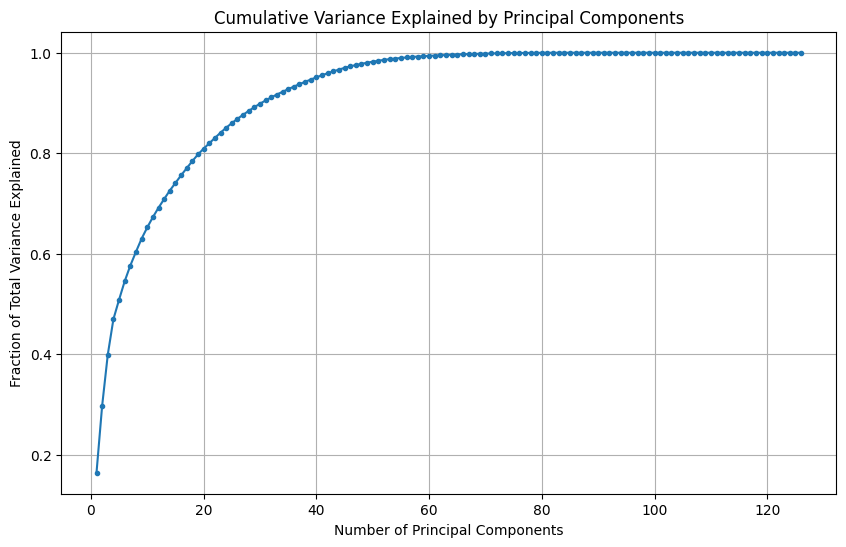

In [ ]:
def P1():
    ### STUDENT START ###

    # Apply PCA to the training data. By not specifying n_components, we keep all 126 components.
    pca = PCA(random_state=0)
    pca.fit(train_data)

    # Calculate the cumulative sum of the variance explained by the components.
    # pca.explained_variance_ratio_ is an array where each element is the fraction of variance explained by that component.
    cumulative_variance_explained = np.cumsum(pca.explained_variance_ratio_)

    # Print the fraction of total variance for specific values of k.
    print("Fraction of total variance explained by k components:")
    k_values = [1, 2, 3, 4, 5, 10, 20, 30, 40, 50]
    for k in k_values:
        # We index with k-1 because arrays are 0-indexed.
        print(f"\t  k = {k:2}: {cumulative_variance_explained[k-1]:.4f}")

    # Show a lineplot of fraction of total variance vs. number of components.
    plt.figure(figsize=(10, 6))
    # We plot k (from 1 to 126) vs. the cumulative variance
    plt.plot(range(1, len(cumulative_variance_explained) + 1), cumulative_variance_explained, marker='.', linestyle='-')
    plt.title('Cumulative Variance Explained by Principal Components')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Fraction of Total Variance Explained')
    plt.grid(True)
    plt.show()

    ### STUDENT END ###

P1()

### Question 2: PCA for visualization

PCA can be very useful for visualizing data.
1. Project the training data down to 2 dimensions and show as a square scatterplot.
  - Show poisonous examples (labeled 1) in red and non-poisonous examples in green (labeled 0)
  - Here's a reference for plotting: http://matplotlib.org/users/pyplot_tutorial.html

Notes:
* You can use `PCA` to produce a PCA analysis.
* Be sure to add a title, axis labels and a legend to your graph.

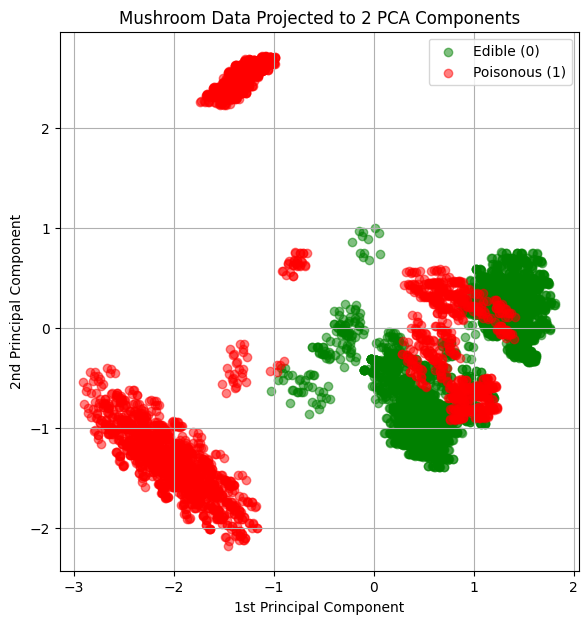

In [ ]:
def Q2():
    ### STUDENT START ###

    # Step 1: Define a PCA model to reduce data to 2 dimensions. We use random_state=0 to ensure our results are reproducible.
    pca_2d = PCA(n_components=2, random_state=0)

    # Step 2: Fit the model on the training data and transform it.
    train_data_2d = pca_2d.fit_transform(train_data)

    # Step 3: Create masks to easily select poisonous vs. edible samples. Edible is label 0, Poisonous is label 1
    edible_mask = (train_labels == 0)
    poisonous_mask = (train_labels == 1)

    # Step 4: Create the plot. We set the figure size to (7, 7) to make it approximately square.
    plt.figure(figsize=(7, 7))

    # Plot the edible (non-poisonous) examples in green.
    plt.scatter(
        train_data_2d[edible_mask, 0],  # 1st Principal Component
        train_data_2d[edible_mask, 1],  # 2nd Principal Component
        c='green',
        label='Edible (0)',
        alpha=0.5 # Use alpha for better visibility of overlapping points
    )

    # Plot the poisonous examples in red.
    plt.scatter(
        train_data_2d[poisonous_mask, 0], # 1st Principal Component
        train_data_2d[poisonous_mask, 1], # 2nd Principal Component
        c='red',
        label='Poisonous (1)',
        alpha=0.5
    )

    # Step 5: Add labels, title, and legend.
    plt.title('Mushroom Data Projected to 2 PCA Components')
    plt.xlabel('1st Principal Component')
    plt.ylabel('2nd Principal Component')
    plt.legend()
    plt.grid(True)

    # Ensures the plot is square
    plt.gca().set_aspect('equal', adjustable='box')

    plt.show()

    ### STUDENT END ###

Q2()

### Question 3: Visualizing GMMs
---

1. Fit a k-means cluster model with 6 clusters over the 2d projected data.
  - As in part 2, show as a square scatterplot with the positive (poisonous) examples in red and the negative (non-poisonous) examples in green.  
  - For each cluster, mark the centroid and plot a circle that goes through the cluster's example that is most distant from the centroid.

Notes:
* You can use `KMeans` to produce a k-means cluster analysis.
* You can use `linalg.norm` to determine distance (dissimilarity) between observations.

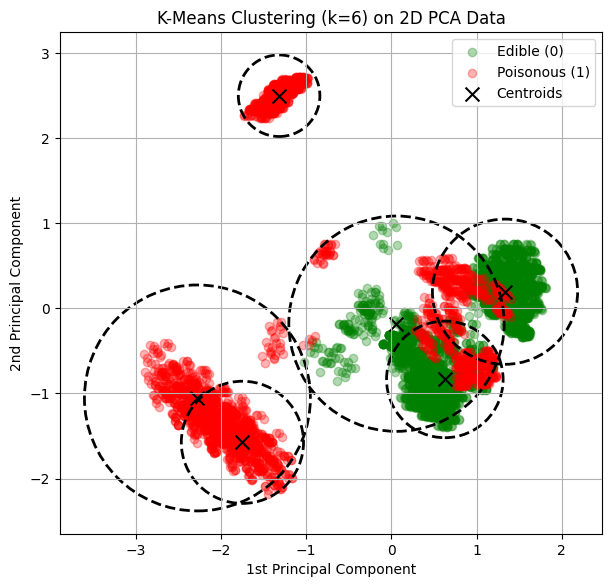

In [ ]:
def Q3():
    ### STUDENT START ###

    # Step 1: Perform PCA to get 2D data (same as Q2)
    pca_2d = PCA(n_components=2, random_state=0)
    train_data_2d = pca_2d.fit_transform(train_data)

    # Step 2: Fit K-Means with 6 clusters
    # We use n_init=10 (the default) and random_state for reproducible results.
    kmeans = KMeans(n_clusters=6, random_state=0, n_init=10)
    kmeans.fit(train_data_2d)

    # Get cluster centroids and labels for each point
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_

    # Step 3: Find the radius of each cluster
    # The radius is the distance from the centroid to the farthest point in the cluster.
    radii = []
    for i in range(6):
        cluster_points = train_data_2d[labels == i] # Get all points belonging to this cluster
        distances = np.linalg.norm(cluster_points - centroids[i], axis=1) # Calculate the Euclidean distance from the centroid to all points
        radii.append(np.max(distances)) # The radius is the maximum distance

    # Step 4: Plot the base scatter plot (same as Q2)
    plt.figure(figsize=(7, 7))

    edible_mask = (train_labels == 0)
    poisonous_mask = (train_labels == 1)

    plt.scatter(train_data_2d[edible_mask, 0],train_data_2d[edible_mask, 1],c='green',label='Edible (0)',alpha=0.3)
    plt.scatter(train_data_2d[poisonous_mask, 0], train_data_2d[poisonous_mask, 1], c='red', label='Poisonous (1)', alpha=0.3)

    # Step 5: Plot the centroids and cluster circles
    ax = plt.gca() # Get the current axes
    for i in range(6):
        # Plot the centroid as a black 'X'
        plt.scatter(centroids[i, 0], centroids[i, 1], marker='x', s=100, c='black',label='Centroids' if i == 0 else "")

        # Create and plot the circle
        circle = plt.Circle( centroids[i],radii[i],facecolor='none', edgecolor='black',linestyle='--',linewidth=2)
        ax.add_patch(circle)

    # Step 6: Add labels, title, and legend
    plt.title('K-Means Clustering (k=6) on 2D PCA Data')
    plt.xlabel('1st Principal Component')
    plt.ylabel('2nd Principal Component')
    plt.legend()
    plt.grid(True)

    # Ensures the plot is square
    ax.set_aspect('equal', adjustable='box')

    plt.show()

    ### STUDENT END ###

Q3()

### Question 4: Understanding GMMs with Density Plots
---

1. Fit Gaussian mixture models for the positive (poisonous) examples in your 2d projected data.
  - Vary the number of mixture components from 1 to 4 and the covariance matrix type 'spherical', 'diag', 'tied', 'full' (that's 16 models).  
  - Show a 4x4 grid of square-shaped plots of the estimated density contours.
    - Each row showing a different number of mixture components.
    - Each column showing a different convariance matrix type.  
1. Be sure to add a title for each plot in the grid to indicate what parameters were used.
1. How are the covariance types 'tied' and 'full' different? How do you see it in the plots?

Notes:
* You can use `GaussianMixture(n_components=..., covariance_type=..., random_state=12345)` to produce a Gaussian mixture model.
* You can use `contour` in combination with other methods to plot contours, like in this example: http://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_pdf.html#example-mixture-plot-gmm-pdf-py
* You can use `contour` without the `norm` and `levels` parameters.

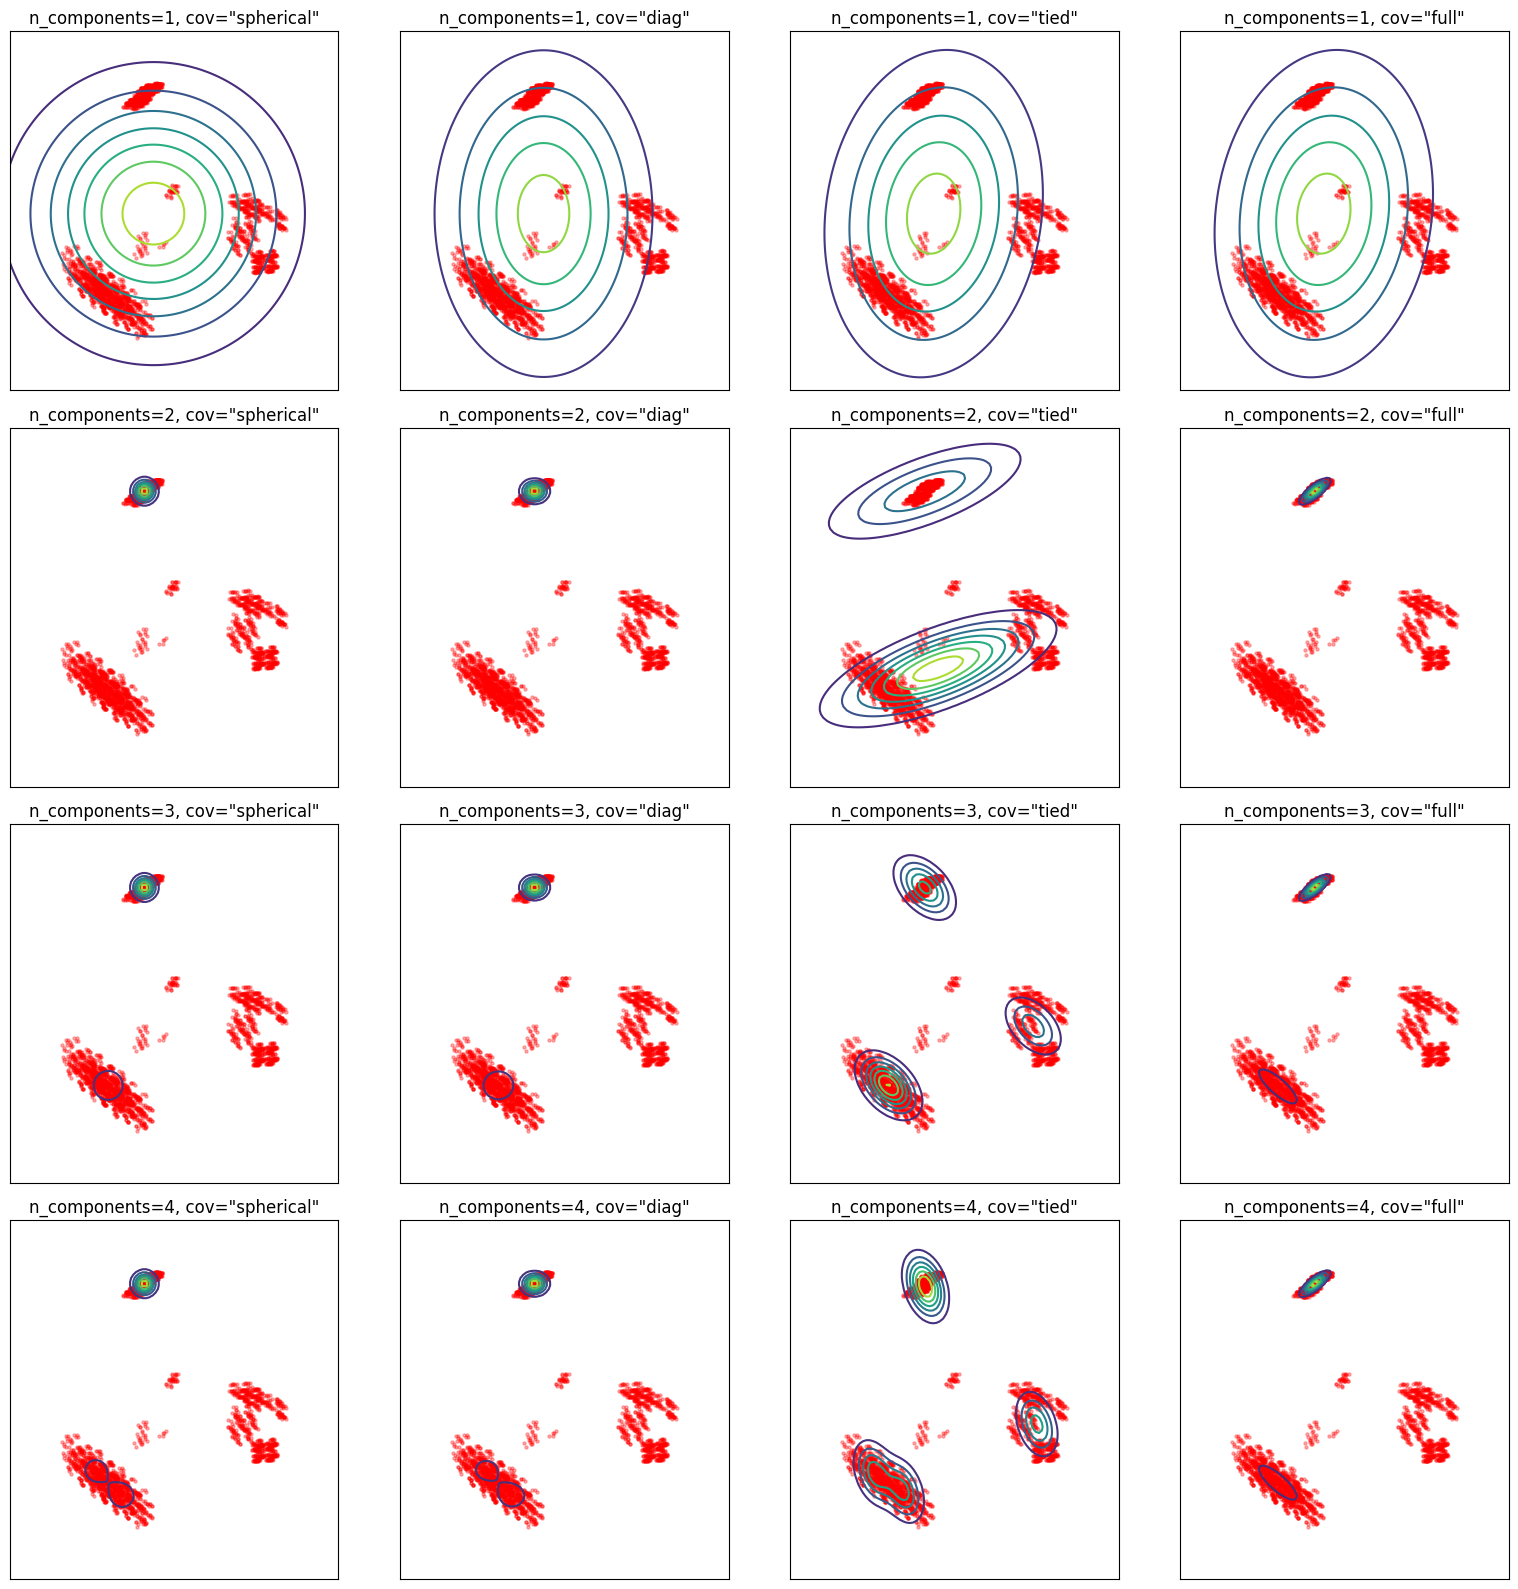

In [ ]:
def Q4():
    ### STUDENT START ###

    # Step 1: Prepare the data  - Perform PCA to get 2D data (same as Q2)
    pca_2d = PCA(n_components=2, random_state=0)
    train_data_2d = pca_2d.fit_transform(train_data)

    # Create a mask for poisonous samples (label 1)
    poisonous_mask = (train_labels == 1)

    # Select only the 2D data for poisonous mushrooms
    poisonous_data_2d = train_data_2d[poisonous_mask]

    # Step 2: Set up GMM parameters and plot grid
    n_components_list = [1, 2, 3, 4]
    covariance_types_list = ['spherical', 'diag', 'tied', 'full']

    # Create a 4x4 grid of subplots
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))

    # Step 3: Create a meshgrid for plotting contours - Find the boundaries of the data to create the grid
    x_min, x_max = poisonous_data_2d[:, 0].min() - 1, poisonous_data_2d[:, 0].max() + 1
    y_min, y_max = poisonous_data_2d[:, 1].min() - 1, poisonous_data_2d[:, 1].max() + 1

    # Create the grid axes
    xx = np.linspace(x_min, x_max, 100)
    yy = np.linspace(y_min, y_max, 100)

    # Create the meshgrid
    XX, YY = np.meshgrid(xx, yy)

    # Step 4: Iterate, fit GMMs, and plot
    for i, n_components in enumerate(n_components_list):
        for j, cov_type in enumerate(covariance_types_list):

            # Select the correct subplot
            ax = axes[i, j]

            # Fit the Gaussian Mixture Model
            gmm = GaussianMixture( n_components=n_components, covariance_type=cov_type,random_state=12345)
            gmm.fit(poisonous_data_2d)

            # Plotting:

            # Calculate the log-probability density for each point on the grid
            Z_log = gmm.score_samples(np.c_[XX.ravel(), YY.ravel()])
            Z = Z_log.reshape(XX.shape)

            # Plot the density contours (using np.exp to convert log-prob to prob-density)
            ax.contour(XX, YY, np.exp(Z))

            # Plot the actual poisonous data points
            ax.scatter(poisonous_data_2d[:, 0], poisonous_data_2d[:, 1], s=5, c='red', alpha=0.3)

            # Formatting:
            ax.set_title(f'n_components={n_components}, cov="{cov_type}"')

            # Set all plots to the same scale for comparison
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)

            # Make the plot square
            ax.set_aspect('equal', adjustable='box')

            # Clean up the plot by removing axis ticks
            ax.set_xticks(())
            ax.set_yticks(())

    # Adjust layout to prevent titles from overlapping
    plt.tight_layout()
    plt.show()

    ### STUDENT END ###

Q4()

Answer:

A - ***How are 'tied' and 'full' covariance types different?***

  - '**full**': Each mixture component gets its own independent covariance matrix. This is the most flexible type, as each cluster can have any elliptical shape and orientation.
  - '**tied**': All mixture components must share the ***same*** covariance matrix. This is more restrictive: all clusters will have the exact same shape and orientation, though their centers can be different.

B - ***How do you see this in the plots?***

  - **In the 'full' plots** (4th column), we can see that as the number of components increases, the ellipses representing them have different shapes and are rotated at different angles.
  - **In the 'tied' plots** (3rd column), all the ellipses for the different components are clearly oriented in the same direction and have the same shape, which is especially visible when n_components > 1.

### Question 5: Using Unsupervised models for classification...?
---

1. Fit two Gaussian mixture models:
  - On your 2d projected training data.
    - Form a subset of all the poisonous examples and fit one GMM (gmm_poison).
    - Form a subset of all the non-poisonous examples and fit another GMM (gmm_nonpoison).
  - Use 4 mixture components and full convariance for each model.  
1. Use the above trained GMMs to classify examples in your test set:
   - For each example in the test set
     - Measure how likely it is to have been "generated" by gmm_poison and gmm_nonpoison (using score_samples).
     - Predict the more likely label.
  - You can use score_samples.
  - You can do this without a for loop which will be more efficient.
1. What is the accuracy of the predictions on the test data? (we expect it to be about 0.95)

Notes:
* You can use `GaussianMixture(n_components=..., covariance_type=..., random_state=12345)` to produce a Gaussian mixture model.
* You can use `GaussianMixture`'s `score_samples` method to find the probabilities.

In [ ]:
def Q5():
  ### STUDENT START ###

  # 1. Generate data_2d (2-d PCA transformed data), split into "positives" and "negatives"

  # Initialize PCA model to get 2 components.  We use the same random_state as previous questions for consistency
  pca_2d = PCA(n_components=2, random_state=0)

  # Fit on training data and transform it
  train_data_2d = pca_2d.fit_transform(train_data)

  # Transform the test data using the *same* PCA model
  test_data_2d = pca_2d.transform(test_data)

  # Create subsets of the 2D training data for poisonous and non-poisonous
  poisonous_data_2d = train_data_2d[train_labels == 1]
  nonpoisonous_data_2d = train_data_2d[train_labels == 0]

  # 2. For each of "positives" and "negatives", train a separate GaussianMixture model

  # Define the GMM parameters
  n_components = 4
  covariance_type = 'full'
  random_state = 12345

  # Create and fit the GMM for poisonous mushrooms
  gmm_poison = GaussianMixture(n_components=n_components, covariance_type=covariance_type,random_state=random_state)
  gmm_poison.fit(poisonous_data_2d)

  # Create and fit the GMM for non-poisonous (edible) mushrooms
  gmm_nonpoison = GaussianMixture( n_components=n_components, covariance_type=covariance_type,random_state=random_state)
  gmm_nonpoison.fit(nonpoisonous_data_2d)

  # 3. Classify test samples and evaluate accuracy

  # Get the log-likelihood that each test sample was generated by each model. score_samples() returns the log-probability
  log_likelihood_poison = gmm_poison.score_samples(test_data_2d)
  log_likelihood_nonpoison = gmm_nonpoison.score_samples(test_data_2d)

  # Predict the label. A higher log-likelihood means a better fit.
  # We predict 1 (poisonous) if the poison model gives a higher score, and 0 (edible) otherwise.
  # We can do this without a loop using numpy's array comparison.
  # (log_likelihood_poison > log_likelihood_nonpoison) creates a boolean array, and .astype(int) converts True -> 1 and False -> 0.
  predictions = (log_likelihood_poison > log_likelihood_nonpoison).astype(int)

  # 4. Calculate and report the accuracy
  accuracy = metrics.accuracy_score(test_labels, predictions)

  print(f"Accuracy of the GMM classifier on the test data: {accuracy:.4f}")

  ### STUDENT END ###

Q5()

Accuracy of the GMM classifier on the test data: 0.9493


### Question 6: Understanding the GMM parameters
---

1. Run a series of experiments to find the Gaussian mixture model that results in the best accuracy with no more than 50 parameters.  Do this by varying the number of PCA components, the number of GMM components, and the covariance type.
1. Print the best configuration and accuracy.
1. Plot a scatter plot of accuracy vs #params.
1. Bonus: Provide a better visualization by showing all four: accuracy, number of parameters, the covariance type and the number of PCA dimensions.



Notes:
* You can use `GaussianMixture(n_components=..., covariance_type=..., random_state=12345)` to produce a Gaussian mixture model.
* [This spreadsheet](https://docs.google.com/spreadsheets/d/1LTEOU7q_Tgs4bX_3o2ePjDQrTRToZoc1J5XLlaRbmI0/edit?usp=sharing) should help (accessible from your google @berkeley.edu account)

* Spherical - Each GMM component has a mean per dimension, and one variance.
* Diag - Each GMM component has a mean per dimension and a variance for each dimension.
* full - Each GMM component has a mean per dimension and a "full" covariance matrix. Only the covariance matrix is symmetric, so its $[i,j]$ entry would equal to its $[j,i]$ entry.
* tied - Finally, tied has all components share a single covariance matrix. So each GMM component has a mean per dimension but they all share the same 'full' covariance matrix.

Running experiments to find best model with <= 50 parameters...

Best Configuration (<= 50 Parameters):
	  Accuracy: 0.9698
	  Parameters: 40.0
	  PCA Components: 4
	  GMM Components: 3
	  Covariance Type: tied



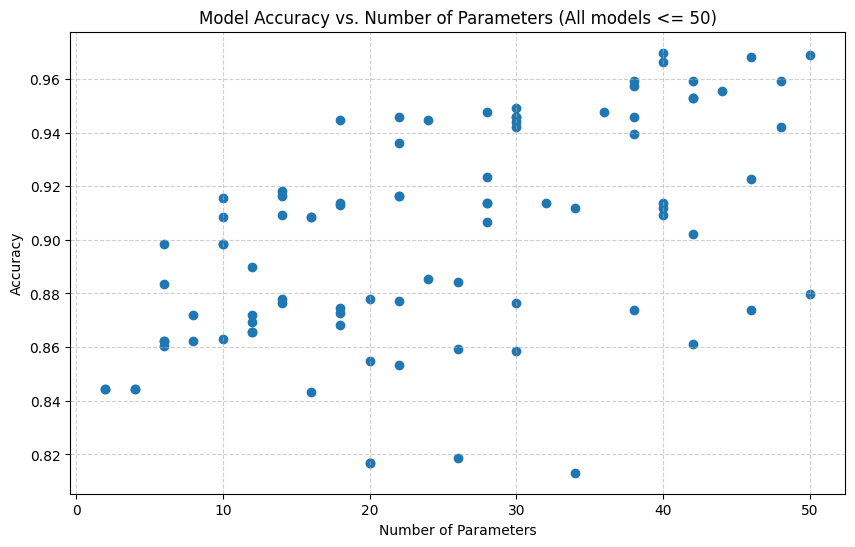

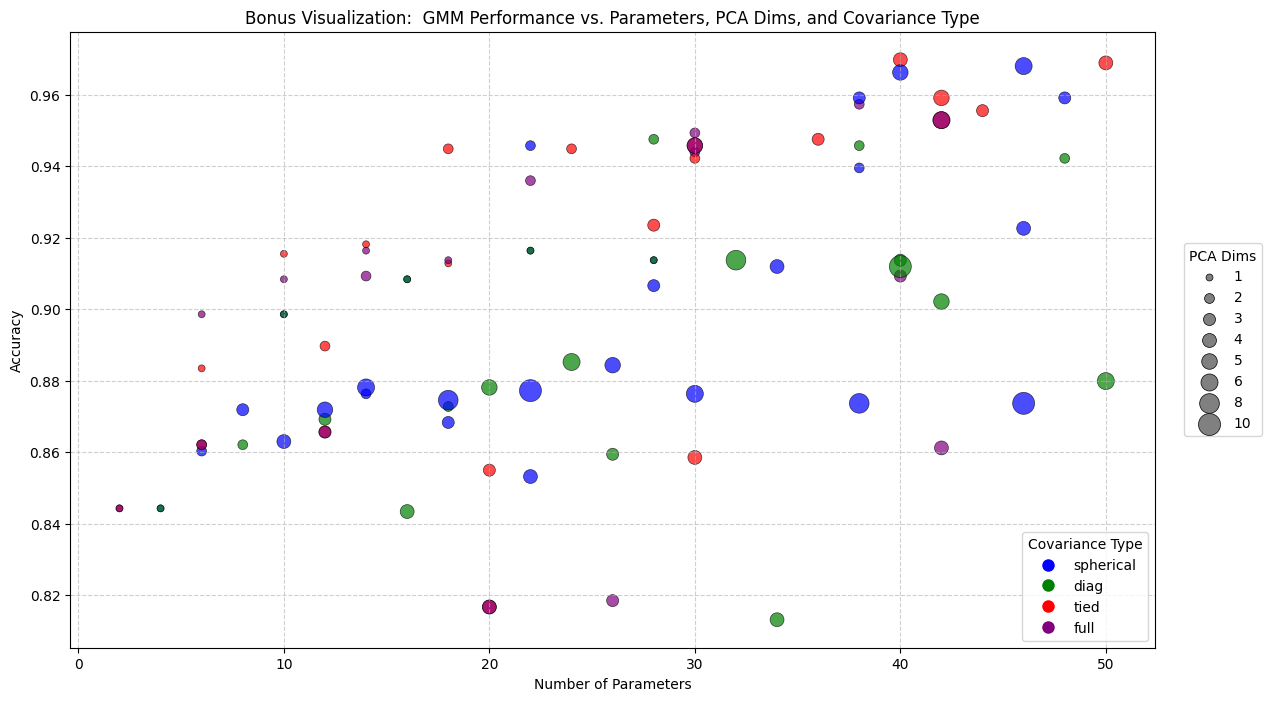

In [ ]:
from matplotlib.lines import Line2D

def param_count(covariance_type, n_classes, n_components, n_dimensions):
  if covariance_type == "spherical":
    mean_params = n_components * n_dimensions
    covariance_params = n_components * 1
    component_weights = n_components - 1
    return n_classes * (mean_params + covariance_params + component_weights)
  elif covariance_type == "diag":
    mean_params = n_components * n_dimensions
    covariance_params = n_components * n_dimensions
    component_weights = n_components - 1
    return n_classes * (mean_params + covariance_params + component_weights)
    pass
  elif covariance_type == "tied":
    mean_params = n_components * n_dimensions
    covariance_params = (n_dimensions * (n_dimensions - 1) / 2)
    component_weights = n_components - 1
    return n_classes * (mean_params + covariance_params + component_weights)
  elif covariance_type == "full":
    mean_params = n_components * n_dimensions
    covariance_params = n_components * (n_dimensions * (n_dimensions - 1) / 2)
    component_weights = n_components - 1
    return n_classes * (mean_params + covariance_params + component_weights)
  raise Exception(f"Unknown covariance type {covariance_type}")



def Q6():
    ### STUDENT START ###

    # Step 1: Define the search space
    # We will vary PCA components, GMM components, and covariance type
    pca_dims_range = [1, 2, 3, 4, 5, 6, 8, 10]
    gmm_comps_range = [1, 2, 3, 4, 5]
    cov_types = ['spherical', 'diag', 'tied', 'full']
    n_classes = 2  # (poisonous, non-poisonous)

    # Lists to store results from all valid experiments
    results = []

    # Step 2: Run the series of experiments
    print("Running experiments to find best model with <= 50 parameters...")

    for n_dim in pca_dims_range:

        # A. Apply PCA for the current number of dimensions
        pca = PCA(n_components=n_dim, random_state=0)
        train_data_pca = pca.fit_transform(train_data)
        test_data_pca = pca.transform(test_data)

        # B. Split the PCA-transformed data into poisonous and edible
        train_poisonous_pca = train_data_pca[train_labels == 1]
        train_edible_pca = train_data_pca[train_labels == 0]

        for n_comp in gmm_comps_range:
            for cov_type in cov_types:

                # C. Calculate the number of parameters for this configuration
                n_params = param_count(cov_type, n_classes, n_comp, n_dim)

                # D. If parameters > 50, skip this experiment
                if n_params > 50:
                    continue

                # E. Train the two GMMs (poisonous and edible)
                try:
                    gmm_poison = GaussianMixture(n_components=n_comp, covariance_type=cov_type,random_state=12345)
                    gmm_poison.fit(train_poisonous_pca)

                    gmm_edible = GaussianMixture(n_components=n_comp,covariance_type=cov_type,random_state=12345)
                    gmm_edible.fit(train_edible_pca)
                except ValueError as e:
                    # This can happen if cov matrix is singular, etc. We'll just skip this configuration.
                    # print(f"Skipping: PCA={n_dim}, GMM={n_comp}, Cov={cov_type} (Fit Error)")
                    continue

                # F. Predict on the test set and calculate accuracy
                scores_poison = gmm_poison.score_samples(test_data_pca)
                scores_edible = gmm_edible.score_samples(test_data_pca)
                predictions = (scores_poison > scores_edible).astype(int)
                accuracy = metrics.accuracy_score(test_labels, predictions)

                # G. Store the results
                results.append({
                    "accuracy": accuracy,
                    "params": n_params,
                    "pca_dims": n_dim,
                    "gmm_comps": n_comp,
                    "cov_type": cov_type
                })

    # Step 3: Find and Print the Best Configuration

    # Sort results by accuracy (highest first)
    best_config = sorted(results, key=lambda x: x['accuracy'], reverse=True)[0]

    print("\nBest Configuration (<= 50 Parameters):")
    print(f"\t  Accuracy: {best_config['accuracy']:.4f}")
    print(f"\t  Parameters: {best_config['params']}")
    print(f"\t  PCA Components: {best_config['pca_dims']}")
    print(f"\t  GMM Components: {best_config['gmm_comps']}")
    print(f"\t  Covariance Type: {best_config['cov_type']}\n")

    # Step 4: Plot Accuracy vs. Number of Parameters

    # Unpack results for plotting
    accuracies = [r['accuracy'] for r in results]
    num_params = [r['params'] for r in results]

    plt.figure(figsize=(10, 6))
    plt.scatter(num_params, accuracies)
    plt.title('Model Accuracy vs. Number of Parameters (All models <= 50)')
    plt.xlabel('Number of Parameters')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Step 5: Bonus Visualization

    # Unpack the other dimensions for the bonus plot
    pca_dims_list = [r['pca_dims'] for r in results]
    cov_types_list = [r['cov_type'] for r in results]

    plt.figure(figsize=(14, 8))

    # Map covariance type to a color
    color_map = {'spherical': 'blue', 'diag': 'green', 'tied': 'red', 'full': 'purple'}
    colors = [color_map[c] for c in cov_types_list]

    # Map PCA dimensions to marker size (scaled for visibility)
    sizes = (np.array(pca_dims_list) * 25)

    # Create the scatter plot
    plt.scatter(num_params, accuracies, c=colors, s=sizes, alpha=0.7, edgecolors='black', linewidth=0.5)

    plt.title('Bonus Visualization:  GMM Performance vs. Parameters, PCA Dims, and Covariance Type')
    plt.xlabel('Number of Parameters')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Create custom legends

    # Color legend for Covariance Type
    color_legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='spherical', markerfacecolor='blue', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='diag', markerfacecolor='green', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='tied', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='full', markerfacecolor='purple', markersize=10)
    ]
    color_legend = plt.legend(handles=color_legend_elements, title="Covariance Type", loc="lower right")
    plt.gca().add_artist(color_legend) # Add the first legend

    # Size legend for PCA Dims
    unique_dims = sorted(list(set(pca_dims_list)))
    size_legend_handles = []
    for dim in unique_dims:
        size_legend_handles.append(
            plt.scatter([], [], s=(dim * 25), c='gray', label=str(dim), edgecolors='black', linewidth=0.5)
        )
    plt.legend(handles=size_legend_handles, title="PCA Dims", loc="center left", bbox_to_anchor=(1.02, 0.5))

    plt.show()

    ### STUDENT END ###

Q6()